# Part I: Weighting Function

Question 1: Optical Depths


We are given the extinction profile

$$
\beta_e(z)=Ce^{-z/H}
$$

where $C$ is the gas concentration coefficient and $H$ is the scale height.

The optical depth from the surface to height $z$ is

$$
\tau(0,z)=\int_0^z \beta_e(z')\,dz'
=\int_0^z Ce^{-z'/H}\,dz'
$$

which gives

$$
\tau(0,z)=CH\left(1-e^{-z/H}\right)
$$

The optical depth from height $z$ to the top of the atmosphere is

$$
\tau(z,\infty)=\int_z^\infty \beta_e(z')\,dz'
=\int_z^\infty Ce^{-z'/H}\,dz'
$$

so

$$
\tau(z,\infty)=CH e^{-z/H}
$$

The total atmospheric optical depth is

$$
\tau^*=\tau(0,\infty)=CH
$$



Question 2: The flux transmittance from z to TOA

Based on class notes, for the flux transmittance we can't use $\tau / \mu$ anymore because that's only for one direction, while here flux means transmittance over all directions. As a result, we have a new parameter called diffusivity factor r: 

$$
t_F=\exp[-r\,\tau]
$$

For our case:

$$
t_F(z,\infty)=\exp[-r\,\tau(z,\infty)]
$$

Substituting $\tau(z,\infty)=CH e^{-z/H}$ gives:

$$
t_F(z,\infty)=\exp\left[-rCH e^{-z/H}\right]
$$



Question 3: The upwelling flux weighting function:

In an absorbing atmosphere the upwelling flux weighting function is:

$$
W_F^\uparrow(z)=\frac{d}{dz}t_F(z,\infty)
$$

Taking the derivative, we have:


$$
W_F^\uparrow(z)=r\,\beta_e(z)\,t_F(z,\infty).
$$

Substituting the expressions for $\beta_e(z)$ and $t_F(z,\infty)$ gives

$$
W_F^\uparrow(z)=rC e^{-z/H}\exp\left[-rCH e^{-z/H}\right].
$$



Question 4: Dependence on gas concentration

The gas concentration is defined as

$$
C=f\times 1.25\times 10^{-4}\ \mathrm{m^{-1}}.
$$


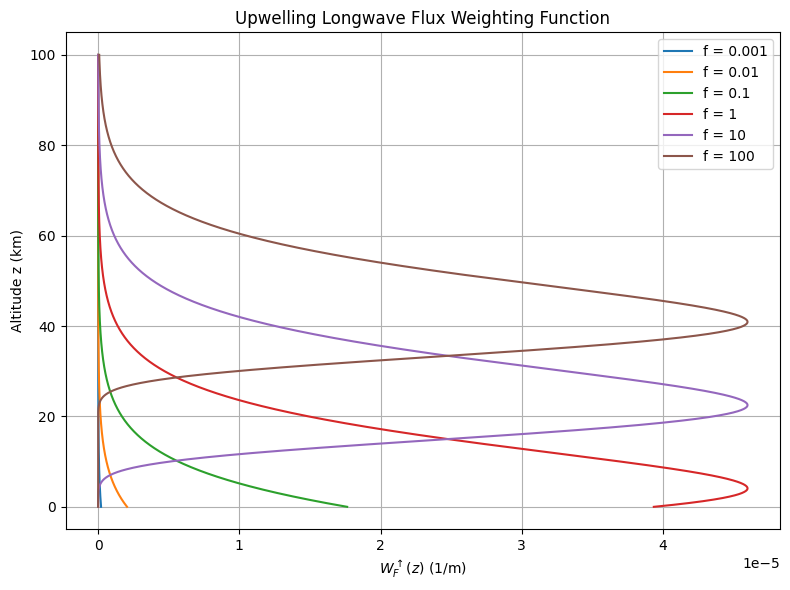

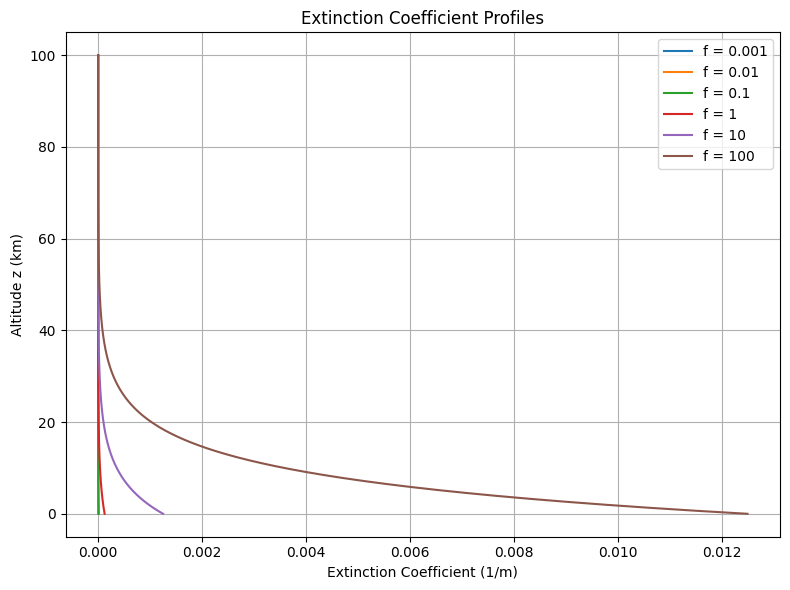

In [71]:
import numpy as np
import matplotlib.pyplot as plt

#define parameters
r = 5/3 # diffusivity factor assumed by the homework
H = 8000 #assumed atmospheric scale height in units of meters
f_values = [0.001, 0.01, 0.1, 1, 10, 100]
z = np.linspace(0, 100000, 2000) #define atmospheric height between 0 to 100 km
z_km = z/1000

#define extinction coefficient
def beta_e(z, c, H):
    return c*np.exp(-z/H)

#define optical depth
def tau_z_inf(z, c, H):
    return c*H*np.exp(-z/H)

#define flux transmittance
def t_z_inf(r, c, H, z):
    return np.exp(-r*tau_z_inf(z, c, H))

#define weighting function
def w_up(z, c, H, r):
    return r*beta_e(z, c, H)*t_z_inf(r, c, H, z)

# Plot w_up
plt.figure(figsize=(8, 6))

for f in f_values:
    c = f * 1.25e-4
    w = w_up(z, c, H, r)
    plt.plot(w, z_km, label=f"f = {f}")

plt.xlabel(r"$W_F^\uparrow(z)$ (1/m)")
plt.ylabel("Altitude z (km)")
plt.title("Upwelling Longwave Flux Weighting Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot beta_e
plt.figure(figsize=(8, 6))

for f in f_values:
    c = f * 1.25e-4
    beta = beta_e(z, c, H)
    plt.plot(beta, z_km, label=f"f = {f}")

plt.xlabel("Extinction Coefficient (1/m)")
plt.ylabel("Altitude z (km)")
plt.title("Extinction Coefficient Profiles")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




For small $f$, the gas is optically thin, so radiation from low altitudes can escape directly to space. The weighting function is therefore largest near the surface. As $f$ increases, the optical depth increases and low-altitude emission becomes less able to escape. The peak of $W_F^\uparrow(z)$ shifts upward, meaning the effective emission level moves to higher altitude. Thus, increasing $f$ causes the outgoing longwave radiation to originate from higher layers of the atmosphere. 

Question 5:

As the scaling factor $f$ increases, the gas concentration and extinction coefficient increases, making the atmosphere more optically thick. This affects the outgoing longwave radiation in two ways. First, because of the high concentration of optically thick gas, the surface-to-space transmittance decreases so less surface emission escapes directly to the top of the atmosphere.

Second, the upwelling weighting function $W_F^\uparrow(z)$ shifts upward. This means that the radiation reaching the top of the atmosphere originates from progressively higher levels in the atmosphere rather than from the warm surface and lower troposphere. In a typical atmosphere where temperature decreases with height, higher layers are colder and therefore emit less radiation. As a result, increasing $f$ generally decreases the outgoing longwave radiation at the top of the atmosphere.

# Part II: TOA Longwave Radiation

Question 1:

Based on the expressions we derived in class, the upward intensity of longwave radiance exiting TOA is:

$$
I^\uparrow_\lambda(\infty)
=
I^\uparrow_\lambda(0)t^*
+
\int_0^\infty B_\lambda(T(z))\,W^\uparrow(z)\,dz
$$

For $I^\uparrow_\lambda(0)$ we have reflection and emission from surface:

$$
I^\uparrow_\lambda(0)
= (1-\epsilon_{s,\lambda})I^\downarrow_\lambda(0) 
+
\epsilon_{s,\lambda}B_\lambda(T_s)
$$

For $I^\downarrow_\lambda(0)$ reaching the surface:

$$
I^\downarrow_\lambda(0)=\int_0^\infty B_\lambda(T(z))\,W^\downarrow(z)\,dz
$$

Inserting into our $I^\uparrow_\lambda(0)$ equation:

$$
I^\uparrow_\lambda(0)=(1-\epsilon_{s,\lambda})\int_0^\infty B_\lambda(T(z))\,W^\downarrow(z)\,dz+\epsilon_{s,\lambda}B_\lambda(T_s)
$$

Then, we insert this into our original $I^\uparrow_\lambda(\infty)$ equation:

$$
I^\uparrow_\lambda(\infty)
=
\left[(1-\epsilon_{s,\lambda})\int_0^\infty B_\lambda(T(z))\,W^\downarrow(z)\,dz+\epsilon_{s,\lambda}B_\lambda(T_s)\right]t^*
+
\int_0^\infty B_\lambda(T(z))\,W^\uparrow(z)\,dz
$$

To calculate the flux, we need to integrate the intensity over all the directions:

$$
F^\uparrow_\lambda(\infty)
=
\pi\left[(1-\epsilon_{s,\lambda})\int_0^\infty B_\lambda(T(z))\,W_F^\downarrow(z)\,dz+\epsilon_{s,\lambda}B_\lambda(T_s)\right]t_F(0,\infty)
+
\pi\int_0^\infty B_\lambda(T(z))\,W_F^\uparrow(z)\,dz
$$

in which we have:

$$
\tau(0,z)=CH\left(1-e^{-z/H}\right)
\qquad
\tau(z,\infty)=CH e^{-z/H}
$$

Thus the flux transmittances are

$$
t_F(0,\infty)=e^{-rCH}
$$

$$
t_F(z,\infty)=\exp\left[-rCH e^{-z/H}\right]
$$

$$
t_F(0,z)=\exp\left[-rCH\left(1-e^{-z/H}\right)\right]
$$

and


$$
W^\uparrow(z)=rCe^{-z/H}\exp\left[-rCH e^{-z/H}\right]
$$

$$
W^\downarrow(z)=rCe^{-z/H}\exp\left[-rCH\left(1-e^{-z/H}\right)\right]
$$

$$
B_\lambda(T)=\frac{2hc^2}{\lambda^5}\frac{1}{\exp\left(\frac{hc}{\lambda k_B T}\right)-1}
$$


Since surface has an emissivity of 1:

$$
F^\uparrow_\lambda(\infty)
=
\pi\epsilon_{s,\lambda}B_\lambda(T_s)*t_F(0,\infty)
+
\pi\int_0^\infty B_\lambda(T(z))\,W_F^\uparrow(z)\,dz
$$

Question 2:


The monochromatic net flux is defined as:

$$
F_{n,\lambda}=F^\downarrow_\lambda-F^\uparrow_\lambda
$$

At the top of the atmosphere:

$$
F_{n,\lambda}(\infty)=F^\downarrow_\lambda(\infty)-F^\uparrow_\lambda(\infty)
$$

For terrestrial longwave radiation, we normally assume there is no incoming longwave flux from space, so:

$$
F^\downarrow_\lambda(\infty)=0.
$$

So the net monochromatic flux at TOA is:

$$
F_{n,\lambda}(\infty)=-F^\uparrow_\lambda(\infty)
$$

Using the result from Question 1,

$$
F^\uparrow_\lambda(\infty)
=
\pi\epsilon_{s,\lambda}B_\lambda(T_s)
*t_F(0,\infty)
+
\pi\int_0^\infty B_\lambda(T(z))\,W_F^\uparrow(z)\,dz
$$

Then we have:

$$
F_{n,\lambda}(\infty)
=
-\pi\epsilon_{s,\lambda}B_\lambda(T_s)
*t_F(0,\infty)
-
\pi\int_0^\infty B_\lambda(T(z))\,W_F^\uparrow(z)\,dz
$$


Now we can insert the transmittance and weighting function equations from part I:

$$
t_F(0,\infty)=e^{-rCH}
$$

and

$$
W_F^\uparrow(z)=rCe^{-z/H}\exp\left[-rCH e^{-z/H}\right],
$$

the final expression becomes

$$
F_{n,\lambda}(\infty)
=
-\pi B_\lambda(T_s)e^{-rCH}
-
\pi\int_0^\infty B_\lambda(T(z))\,rCe^{-z/H}\exp\left[-rCH e^{-z/H}\right]\,dz
$$


The gas concentration is defined as

$$
C = f \times 1.25 \times 10^{-4}\ \mathrm{m^{-1}}.
$$

considering:

$$
C_0 = 1.25 \times 10^{-4}\ \mathrm{m^{-1}}, \qquad C = f C_0.
$$

Substituting this into the expression for the monochromatic net flux at TOA:

$$
F_{n,\lambda}(\infty; f)
=
-\pi B_\lambda(T_s)\,e^{-r f C_0 H}
-
\pi \int_0^\infty
B_\lambda(T(z))\,
r f C_0\, e^{-z/H}
\exp\left[-r f C_0 H e^{-z/H}\right]
\,dz.
$$

This expression gives the TOA monochromatic net flux as a function of $f$. 

The radiative forcing of our gas is defined as below:

$$
\Delta F(\infty; f)
=
F_{n,\lambda}(\infty; f)
-
F_{n,\lambda}(\infty; f=0).
$$

Using the expression for $F_{n,\lambda}(\infty; f)$, we can calculate the reference case with no absorbing gas with $f=0$ and $C=0$:

- $t_F(0,\infty)=1$
- $W_F^\uparrow(z)=0$

Thus,

$$
F_{n,\lambda}(\infty; 0)
=
-\pi B_\lambda(T_s).
$$

Therefore, the radiative forcing becomes

$$
\Delta F(\infty; f)
=
-\pi B_\lambda(T_s)\left(e^{-r f C_0 H} - 1\right)
-
\pi \int_0^\infty
B_\lambda(T(z))\,
r f C_0\, e^{-z/H}
\exp\left[-r f C_0 H e^{-z/H}\right]
\,dz
$$

In [70]:
#######################Model functions########################
# constants for plank function
h = 6.62607015e-34      # Planck constant (J s)
c_light = 2.99792458e8  # speed of light (m s^-1)
kB = 1.380649e-23       # Boltzmann constant (J K^-1)

# homework parameters
r = 5/3
H = 8000.0                       # m
C0 = 1.25e-4                     # m^-1
wavelength = 15e-6                      # 15 microns in meters
Ts = 300.0                       # surface temperature (K)

z = np.linspace(0, 100000, 10000) # 0 to 100 km in m
z_km = z / 1000

# extinction coefficient
def beta_e(z, c, H):
    return c * np.exp(-z / H)

# optical depth from z to infinity
def tau_z_inf(z, c, H):
    return c * H * np.exp(-z / H)

# flux transmittance from z to infinity
def t_z_inf(r, c, H, z):
    return np.exp(-r * tau_z_inf(z, c, H))

# upwelling weighting function
def w_up(z, c, H, r):
    return r * beta_e(z, c, H) * t_z_inf(r, c, H, z)

# Planck function B_lambda(T)
def planck_lambda(wavelength, T):
    exponent = h * c_light / (wavelength * kB * T)
    return (2 * h * c_light**2 / wavelength**5) / (np.exp(exponent) - 1)

# temperature profile 
def T_profile_case_1(z):
    return np.full_like(z, 300.0)

# monochromatic net flux at TOA
def F_net_TOA(f, z, H, r, wavelength, T_profile_func):
    c = f * C0
    Tz = T_profile_func(z)

    surface_term = -(np.pi * planck_lambda(wavelength, Ts) * np.exp(-r * c * H))

    atm_integrand = -(np.pi * planck_lambda(wavelength, Tz) * w_up(z, c, H, r))
    atm_term = np.trapezoid(atm_integrand, z)

    return surface_term + atm_term

#define radiative forcing
def radiative_forcing(f, z, H, r, wavelength, T_profile_func):
    return F_net_TOA(f, z, H, r, wavelength, T_profile_func) - F_net_TOA(0.0, z, H, r, wavelength, T_profile_func)

# generate f values (log-spaced)
f_plot = np.logspace(-3, 2, 200)
f_values = np.array([0.001, 0.01, 0.1, 1, 10, 100])

########Calculate where the peak emission height is for each f value
# peak emission height
def z_peak(f, z, H, r):
    c = f * C0
    W = w_up(z, c, H, r)
    return z[np.argmax(W)]
z_peak_vals = np.array([z_peak(f, z, H, r) for f in f_plot]) / 1000  # km


# Case 1:

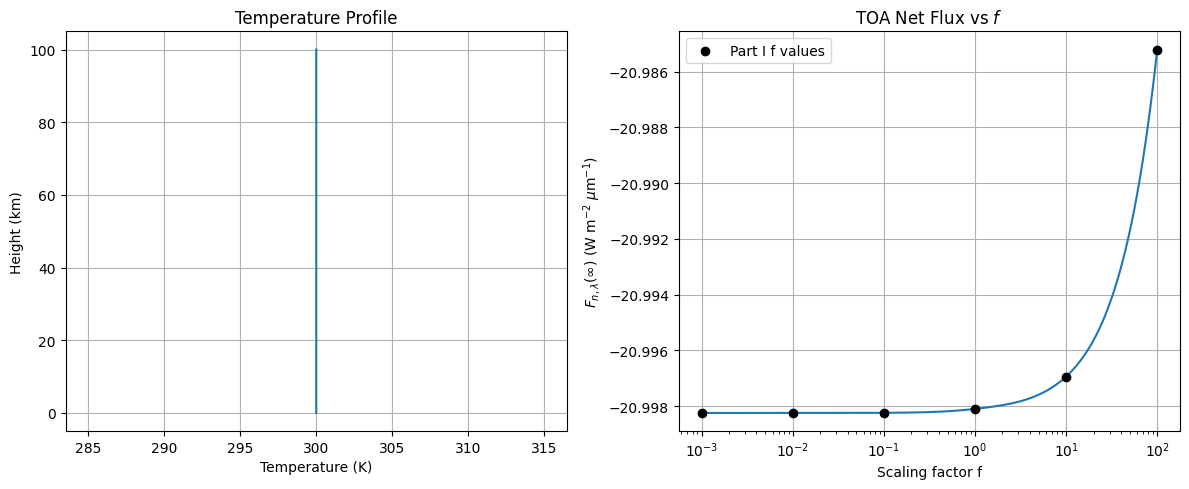

f       F_n,lambda(infinity) [W m^-2 um^-1]
0.001   -2.099825e+01
0.01    -2.099825e+01
0.1     -2.099824e+01
1       -2.099810e+01
10      -2.099694e+01
100     -2.098521e+01


In [72]:
Fnet_values = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_1) for f in f_plot])
Fnet_values_um = Fnet_values * 1e-6  # convert from W/m^2 to W/m^2/um
Fn_points = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_1) for f in f_values]) * 1e-6 #F net for given f values

#plot temperature profile and Fnet vs f
Tz = T_profile_case_1(z)

# create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Flux vs f ---
axes[1].plot(f_plot, Fnet_values_um)
axes[1].scatter(f_values, Fn_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$F_{n,\lambda}(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Net Flux vs $f$")
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("f       F_n,lambda(infinity) [W m^-2 um^-1]")
for f in f_values:
    Fn = F_net_TOA(f, z, H, r, wavelength, T_profile_case_1) * 1e-6
    print(f"{f:<7} {Fn:.6e}")


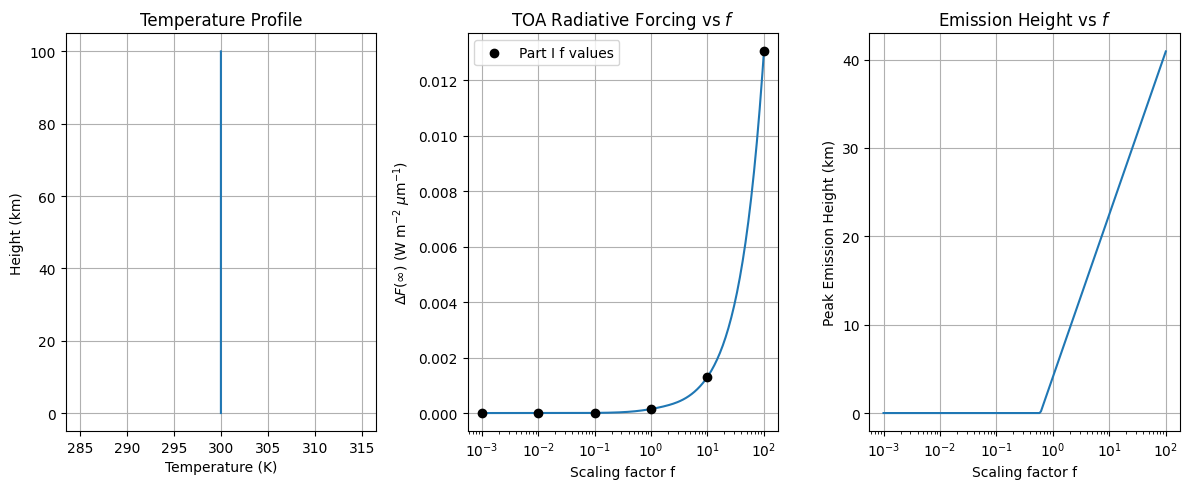

f       Delta F(infinity) [W m^-2 um^-1]
0.001   1.676533e-08
0.01    2.013973e-07
0.1     4.998064e-06
1       1.447812e-04
10      1.304185e-03
100     1.303819e-02
Validation of weighting function integral:
1 (np.float64(0.8111175022444779), np.float64(0.8111243971624382))
10 (np.float64(0.9999378330136417), np.float64(0.9999999422225148))
100 (np.float64(0.9993790819648196), np.float64(1.0))
1000 (np.float64(0.9938081403295187), np.float64(1.0))


In [73]:
# compute forcing
DeltaF_values = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_1) for f in f_plot])
DeltaF_values_um = DeltaF_values * 1e-6  # convert to W m^-2 um^-1
DeltaF_points = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_1) for f in f_values]) * 1e-6 #for part I f values

# create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Delta Flux vs f ---
axes[1].plot(f_plot, DeltaF_values_um)
axes[1].scatter(f_values, DeltaF_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$\Delta F(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Radiative Forcing vs $f$")
axes[1].grid(True)

# --- Plot 3: Emission Height vs f ---
axes[2].plot(f_plot, z_peak_vals)
axes[2].set_xscale("log")
axes[2].set_xlabel("Scaling factor f")
axes[2].set_ylabel("Peak Emission Height (km)")
axes[2].set_title("Emission Height vs $f$")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("f       Delta F(infinity) [W m^-2 um^-1]")
for f in f_values:
    dF = radiative_forcing(f, z, H, r, wavelength, T_profile_case_1) * 1e-6
    print(f"{f:<7} {dF:.6e}")
    
def check_weight_integral(f):
    c = f * C0
    W = w_up(z, c, H, r)
    integral = np.trapezoid(W, z)
    t_surface = np.exp(-r * c * H)
    return integral, 1 - t_surface
print("Validation of weighting function integral:")
for f in [1, 10, 100, 1000]:
    print(f, check_weight_integral(f))

For an isothermal atmosphere, we have:

$$
T(z)=300\ \mathrm{K}
$$

at all heights. In this case, as $f$ increases, the weighting function $W_F^\uparrow(z)$ still shifts upward because the atmosphere becomes more optically thick. However, every altitude emits at the same temperature as the surface. Therefore, the atmospheric emission that replaces the attenuated surface emission has the same Planck radiance, so shifting the upwelling weighting function upward does not change the emission temperature. As a result, the TOA monochromatic net flux remains approximately constant as $f$ changes, and the radiative forcing

$$
\Delta F(\infty;f)
=
F_{n,\lambda}(\infty;f)-F_{n,\lambda}(\infty;0) = 0
$$

is approximately zero for all values of $f$. Although the radiative forcing is close to zero, the radiative forcing tends to increase as the f reaches higher values than 100. An explanation that comes to my mind is because f increases, the atmosphere gets optically thicker, which would result in a slight increase in the radiative forcing of our gas. I also performed a validation to see if the integration works perfect, but it seems that for this special case the integration does not converge all the way to 1 at high values of f so that can also be another effective variable here.

# Case 2:

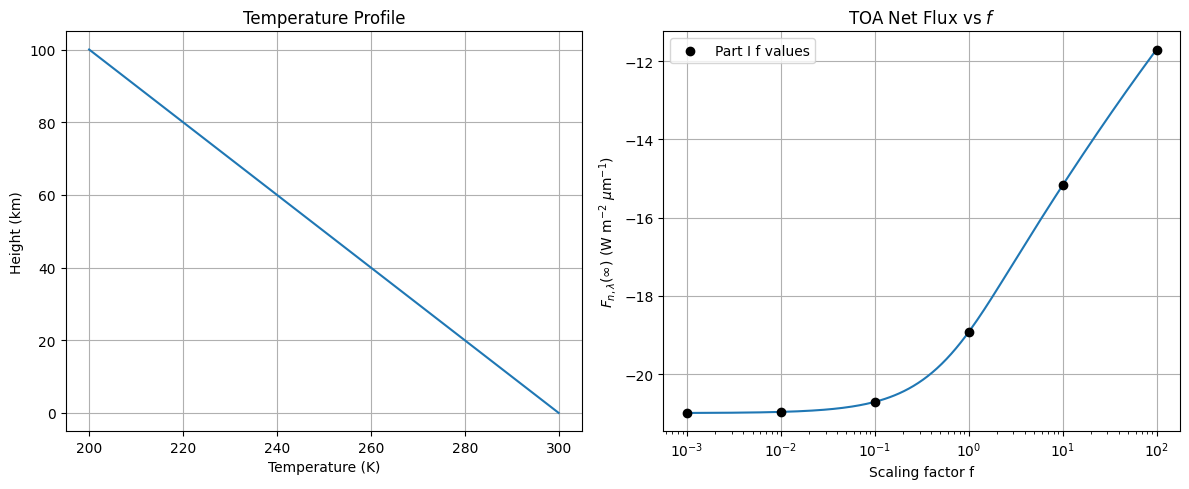

f       F_n,lambda(infinity) [W m^-2 um^-1]
0.001   -2.099526e+01
0.01    -2.096852e+01
0.1     -2.071200e+01
1       -1.892635e+01
10      -1.517339e+01
100     -1.170142e+01


In [74]:
def T_profile_case_2(z):
    z_km = z / 1000.0
    return 300.0 - 1.0 * z_km

Fnet_values = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_2) for f in f_plot])
Fnet_values_um = Fnet_values * 1e-6  # convert from W/m^2 to W/m^2/um
Fn_points = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_2) for f in f_values]) * 1e-6 #F net for given f values

#plot temperature profile and Fnet vs f
Tz = T_profile_case_2(z)

# create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Flux vs f ---
axes[1].plot(f_plot, Fnet_values_um)
axes[1].scatter(f_values, Fn_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$F_{n,\lambda}(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Net Flux vs $f$")
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("f       F_n,lambda(infinity) [W m^-2 um^-1]")
for f in f_values:
    Fn = F_net_TOA(f, z, H, r, wavelength, T_profile_case_2) * 1e-6
    print(f"{f:<7} {Fn:.6e}")


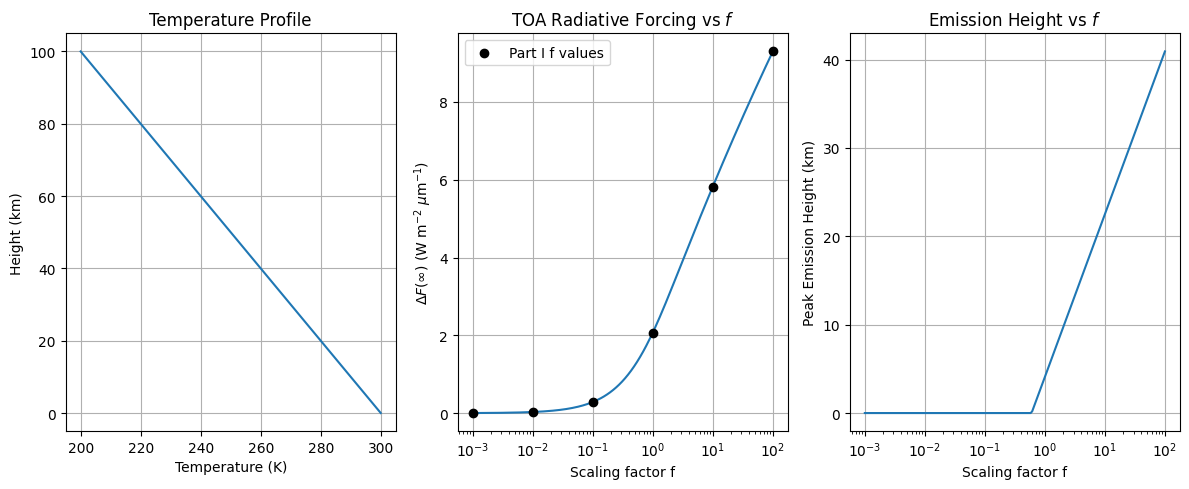

f       Delta F(infinity) [W m^-2 um^-1]
0.001   2.983639e-03
0.01    2.972256e-02
0.1     2.862494e-01
1       2.071897e+00
10      5.824862e+00
100     9.296829e+00


In [75]:
# compute forcing
DeltaF_values = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_2) for f in f_plot])
DeltaF_values_um = DeltaF_values * 1e-6  # convert to W m^-2 um^-1
DeltaF_points = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_2) for f in f_values]) * 1e-6 #for part I f values

# create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Delta Flux vs f ---
axes[1].plot(f_plot, DeltaF_values_um)
axes[1].scatter(f_values, DeltaF_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$\Delta F(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Radiative Forcing vs $f$")
axes[1].grid(True)

# --- Plot 3: Emission Height vs f ---
axes[2].plot(f_plot, z_peak_vals)
axes[2].set_xscale("log")
axes[2].set_xlabel("Scaling factor f")
axes[2].set_ylabel("Peak Emission Height (km)")
axes[2].set_title("Emission Height vs $f$")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("f       Delta F(infinity) [W m^-2 um^-1]")
for f in f_values:
    dF = radiative_forcing(f, z, H, r, wavelength, T_profile_case_2) * 1e-6
    print(f"{f:<7} {dF:.6e}")
    

The shape of $\Delta F(\infty)$ is controlled by both the upwelling weighting function $W_F^\uparrow(z)$ and the atmospheric temperature profile. For very small $f$, the atmosphere is optically thin, so the weighting function is concentrated near the surface. The peak emission height remains close to 0 km, so the outgoing radiation mainly comes from the warm earth's surface and lower atmosphere. As a result, the TOA monochromatic flux remains close to the $f=0$ case, and $\Delta F(\infty)$ stays near zero.

As $f$ increases, the atmosphere becomes more optically thick and the weighting function shifts upward (starting from f values near 1). The emission-height plot shows that the emission level rises quickly for intermediate values of $f$, and thus the steep of radiative forcing function also increases. Because the temperature profile decreases from 300 K at the surface to 200 K at 100 km, this upward shift moves the emission to colder levels, reducing the outgoing monochromatic longwave flux. Therefore, $\Delta F(\infty)$ becomes increasingly positive and will continue to increase as the f increases and shifts the weighting function to higher altitudes.


# Case 3

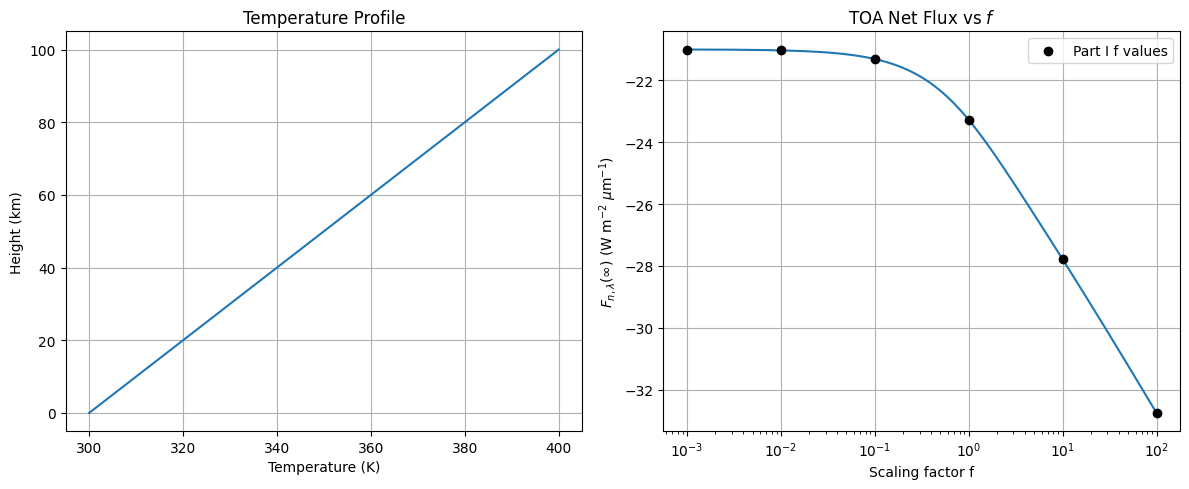

f       F_n,lambda(infinity) [W m^-2 um^-1]
0.001   -2.100147e+01
0.01    -2.103040e+01
0.1     -2.130837e+01
1       -2.327294e+01
10      -2.778091e+01
100     -3.275115e+01


In [76]:
def T_profile_case_3(z):
    z_km = z / 1000.0
    return 300.0 + 1.0 * z_km

Fnet_values = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_3) for f in f_plot])
Fnet_values_um = Fnet_values * 1e-6  # convert from W/m^2 to W/m^2/um
Fn_points = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_3) for f in f_values]) * 1e-6 #F net for given f values

#plot temperature profile and Fnet vs f
Tz = T_profile_case_3(z)

# create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Flux vs f ---
axes[1].plot(f_plot, Fnet_values_um)
axes[1].scatter(f_values, Fn_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$F_{n,\lambda}(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Net Flux vs $f$")
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("f       F_n,lambda(infinity) [W m^-2 um^-1]")
for f in f_values:
    Fn = F_net_TOA(f, z, H, r, wavelength, T_profile_case_3) * 1e-6
    print(f"{f:<7} {Fn:.6e}")


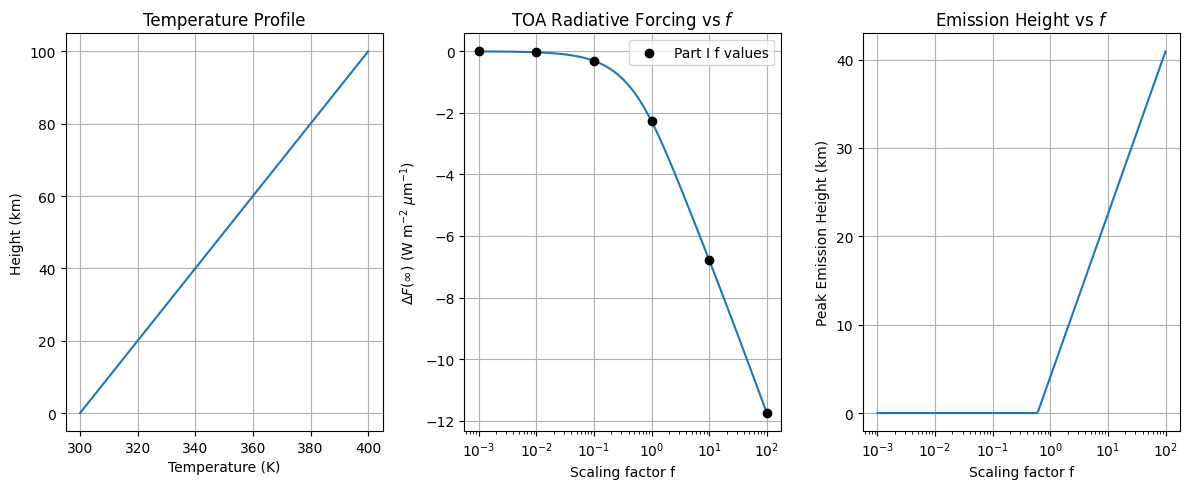

f       Delta F(infinity) [W m^-2 um^-1]
0.001   -3.227319e-03
0.01    -3.215472e-02
0.1     -3.101199e-01
1       -2.274695e+00
10      -6.782658e+00
100     -1.175290e+01


In [77]:
# compute forcing
DeltaF_values = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_3) for f in f_plot])
DeltaF_values_um = DeltaF_values * 1e-6  # convert to W m^-2 um^-1
DeltaF_points = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_3) for f in f_values]) * 1e-6 #for part I f values

# create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Delta Flux vs f ---
axes[1].plot(f_plot, DeltaF_values_um)
axes[1].scatter(f_values, DeltaF_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$\Delta F(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Radiative Forcing vs $f$")
axes[1].grid(True)

# --- Plot 3: Emission Height vs f ---
axes[2].plot(f_plot, z_peak_vals)
axes[2].set_xscale("log")
axes[2].set_xlabel("Scaling factor f")
axes[2].set_ylabel("Peak Emission Height (km)")
axes[2].set_title("Emission Height vs $f$")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("f       Delta F(infinity) [W m^-2 um^-1]")
for f in f_values:
    dF = radiative_forcing(f, z, H, r, wavelength, T_profile_case_3) * 1e-6
    print(f"{f:<7} {dF:.6e}")
    

This case is in a way the opposite of what we had for case 2. For very small $f$, the atmosphere is optically thin, so the weighting function is concentrated near the surface. The peak emission height remains close to 0 km, so the outgoing radiation mainly comes from the warm earth's surface and lower atmosphere. As a result, the TOA monochromatic flux remains close to the $f=0$ case, and $\Delta F(\infty)$ stays near zero.

As $f$ increases, however, the atmosphere becomes more optically thick and the weighting function shifts upward. Because the temperature profile increases from 300 K at the surface to 400 K at 100 km, this upward shift moves the emission to warmer levels, increasing the outgoing monochromatic longwave flux. Therefore, $\Delta F(\infty)$ becomes increasingly negative and will continue to decrease as the f increases and shifts the weighting function to higher altitudes, resulting in a cooling radiative forcing.


# Case 4

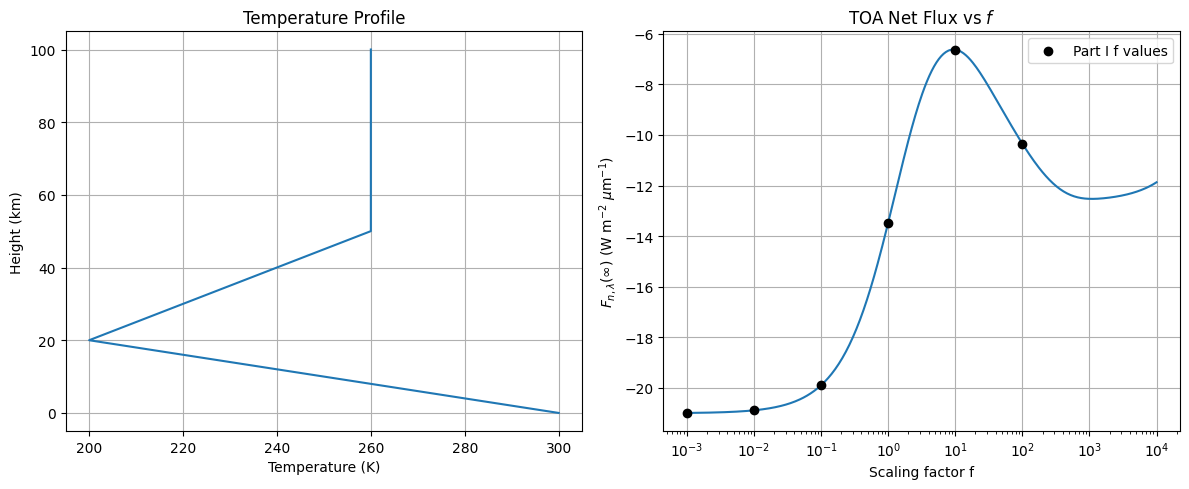

f       F_n,lambda(infinity) [W m^-2 um^-1]
0.001   -2.098662e+01
0.01    -2.088251e+01
0.1     -1.989072e+01
1       -1.346464e+01
10      -6.625874e+00
100     -1.034323e+01


In [78]:
f_plot = np.logspace(-3, 4, 400)

def T_profile_case_4(z):
    z_km = z / 1000.0

    return np.where(
        z_km <= 20,
        300.0 - 5.0 * z_km,
        np.where(
            z_km <= 50,
            200.0 - (-2.0) * (z_km - 20.0),  # same as 200 + 2*(z-20)
            260.0
        )
    )

Fnet_values = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_4) for f in f_plot])
Fnet_values_um = Fnet_values * 1e-6  # convert from W/m^2 to W/m^2/um
Fn_points = np.array([F_net_TOA(f, z, H, r, wavelength, T_profile_case_4) for f in f_values]) * 1e-6 #F net for given f values

#plot temperature profile and Fnet vs f
Tz = T_profile_case_4(z)

# create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Flux vs f ---
axes[1].plot(f_plot, Fnet_values_um)
axes[1].scatter(f_values, Fn_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$F_{n,\lambda}(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Net Flux vs $f$")
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("f       F_n,lambda(infinity) [W m^-2 um^-1]")
for f in f_values:
    Fn = F_net_TOA(f, z, H, r, wavelength, T_profile_case_4) * 1e-6
    print(f"{f:<7} {Fn:.6e}")


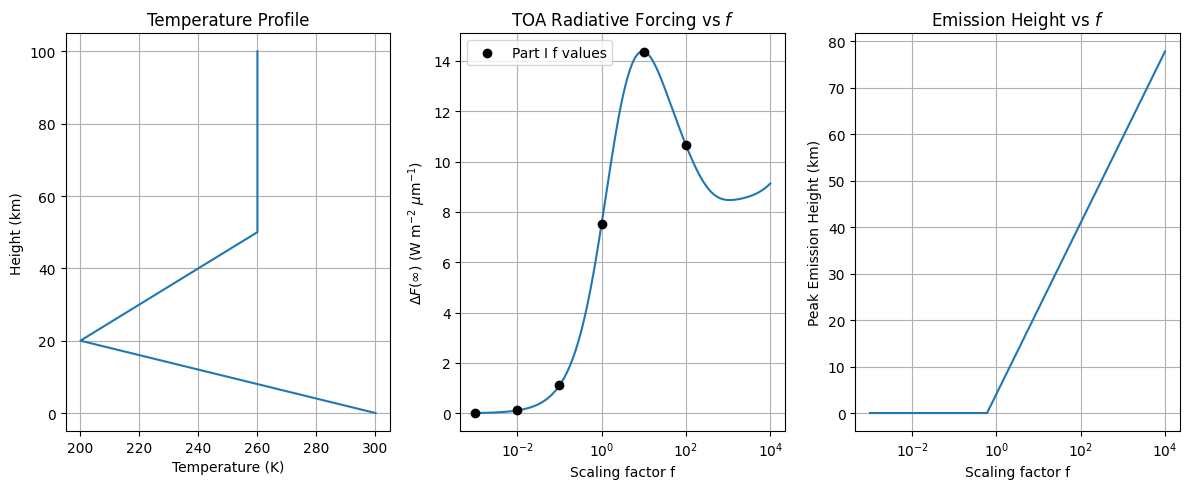

f       Delta F(infinity) [W m^-2 um^-1]
0.001   1.162534e-02
0.01    1.157359e-01
0.1     1.107529e+00
1       7.533612e+00
10      1.437237e+01
100     1.065502e+01


In [79]:
# compute forcing
DeltaF_values = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_4) for f in f_plot])
DeltaF_values_um = DeltaF_values * 1e-6  # convert to W m^-2 um^-1
DeltaF_points = np.array([radiative_forcing(f, z, H, r, wavelength, T_profile_case_4) for f in f_values]) * 1e-6 #for part I f values

# peak emission height
def z_peak(f, z, H, r):
    c = f * C0
    W = w_up(z, c, H, r)
    return z[np.argmax(W)]
z_peak_vals = np.array([z_peak(f, z, H, r) for f in f_plot]) / 1000  # km

# create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Delta Flux vs f ---
axes[1].plot(f_plot, DeltaF_values_um)
axes[1].scatter(f_values, DeltaF_points, color='black', zorder=3, label="Part I f values")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Scaling factor f")
axes[1].set_ylabel(r"$\Delta F(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Radiative Forcing vs $f$")
axes[1].grid(True)

# --- Plot 3: Emission Height vs f ---
axes[2].plot(f_plot, z_peak_vals)
axes[2].set_xscale("log")
axes[2].set_xlabel("Scaling factor f")
axes[2].set_ylabel("Peak Emission Height (km)")
axes[2].set_title("Emission Height vs $f$")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("f       Delta F(infinity) [W m^-2 um^-1]")
for f in f_values:
    dF = radiative_forcing(f, z, H, r, wavelength, T_profile_case_4) * 1e-6
    print(f"{f:<7} {dF:.6e}")
    

In this case, As $f$ increases, the atmosphere becomes more optically thick and the weighting function shifts upward, so the radiation reaching the top of the atmosphere originates from progressively higher levels. For small $f$, the weighting function remains concentrated near the surface, so the outgoing radiation is dominated by the warm lower atmosphere and the forcing remains close to zero.

At intermediate values of $f$ up to f = 10, the weighting function shifts upward through the troposphere, where temperature decreases with height. This reduces the emission temperature and therefore decreases the TOA outgoing monochromatic flux, making $\Delta F(\infty)$ more positive.

At larger $f$, however, the weighting function begins to sample the stratospheric region above 20 km, where temperature increases with height. In this region, moving the emission level higher does not continue to reduce the emitted radiation as strongly, because the atmosphere is no longer getting colder. As a result, the forcing curve starts to go down as the weighting function is in warmer layers compared to below 20 km height, resulting in a less warming radiative forcing.

above 50 km, the temperature stays constant at 260 k. At this point (f is nearly above 100), the weighting function still moves upward as the f increases (I increased the f range for this case for better visualization). However, the temperature is constant so the longwave radiation emission from the weighting function height does not change as it moves upward. As a result, the radiative forcing of our gas above 50 km stays nearly constant up to the top of the atmosphere.

# Part III: Student Investigation

For the investigation, my question is that how does the radiative forcing of our gas at top of the atmosphere changes as we change the scale height? As the scale height is a function of the gravity, I'm going to consider the range between the lowest gravity in solar planets (Mercury with 3.7 $m / s^{2}$) to the highest (Jupiter with 24.79 $m / s^{2}$). However, I have chosen a scale height range between 3000 m to 40000 m to plot the radiative forcing result versus the scale height since it was more interesting, considering the same temperature profile as case 4 and a fixed gas concentration (f=1).

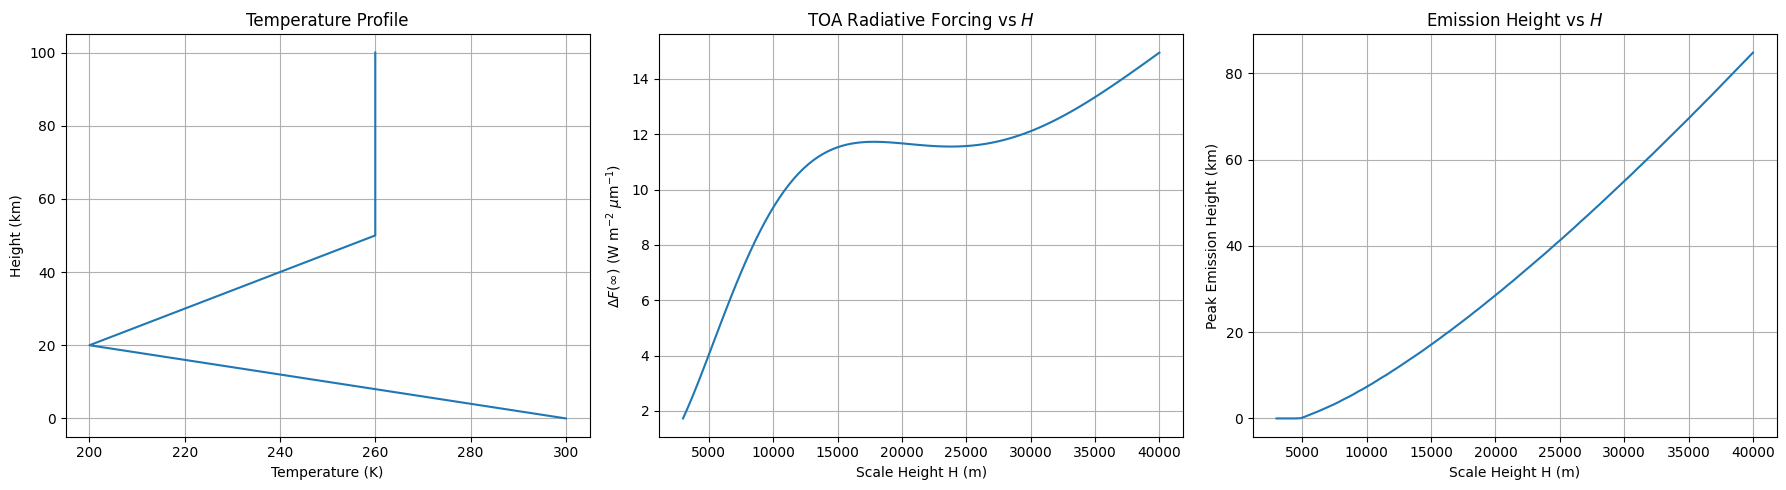

In [80]:

H_plot = np.linspace(3000, 40000, 100)

# compute forcing
DeltaF_values = np.array([radiative_forcing(1, z, H, r, wavelength, T_profile_case_4) for H in H_plot])
DeltaF_values_um = DeltaF_values * 1e-6  # convert to W m^-2 um^-1

z_peak_vals = np.array([z_peak(1, z, H, r) for H in H_plot]) / 1000  # km


# create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Temperature profile ---
axes[0].plot(Tz, z_km)
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("Temperature Profile")
axes[0].grid(True)

# --- Plot 2: Delta Flux vs f ---
axes[1].plot(H_plot, DeltaF_values_um)
#axes[1].legend()
#axes[1].set_xscale("log")
axes[1].set_xlabel("Scale Height H (m)")
axes[1].set_ylabel(r"$\Delta F(\infty)$ (W m$^{-2}$ $\mu$m$^{-1}$)")
axes[1].set_title(r"TOA Radiative Forcing vs $H$")
axes[1].grid(True)

# --- Plot 3: Emission Height vs f ---
axes[2].plot(H_plot, z_peak_vals)
#axes[2].set_xscale("log")
axes[2].set_xlabel("Scale Height H (m)")
axes[2].set_ylabel("Peak Emission Height (km)")
axes[2].set_title(r"Emission Height vs $H$")
axes[2].grid(True)
plt.tight_layout()
plt.show()
    

As the scale height $H$ increases, the gas concentration decreases more slowly with height and the total optical depth increases because

$$
\tau^*=CH
$$

Therefore, for fixed gas concentration $C$, a larger scale height makes the atmosphere more optically thick. This reduces the amount of surface longwave radiation that escapes directly to space and shifts the upwelling weighting function upward. This produces a larger positive radiative forcing, meaning the atmosphere will get warmer compared to lower scale height values. In this scenario, the curve initially increases rapidly because the atmosphere transitions from more transparent to optically thick. Then, it flattens as the surface contribution goes down to down significantly with increased H and also the emission level is not moving into much colder air anymore. After reaching the constant temperature height, I think even though the emission temperature is no longer decreasing, the total optical depth continues increasing strongly with H, which seems to have a stronger effect and increase the radiative forcing.

# AI Usage:



Tool: ChatGPT

Type of use:
1. Plot coding for radiative forcing and weighting function.
2. Creating the temperature profile for various cases.
3. Implementation of weighting function integration.
4. AI was used to help with the loops and logics implementation.